In [1]:
data_set = "spam_or_not_spam.csv"
text_col = "Feedback"
label_col = "Sentiment"

model_name = "distilbert-base-uncased"
test_size = 0.2
num_labels = 2

In [3]:
import pandas as pd 

df_1 = pd.read_csv(data_set)

# Assigns 1 to positive feedback and 0 to negative feedback - creates a new column in original dataframe
# df['safe'] = df['Sentiment'].apply(lambda x: 1 if x=='Positive' else 0)

df_1['label'].value_counts

df_notspam = df_1[df_1['label'] == 0]
df_spam = df_1[df_1['label'] == 1]

notspam_reduced = df_notspam.sample(df_spam.shape[0])
df = pd.concat([df_spam, notspam_reduced])

# df['label'].value_counts()


In [ ]:
from collections import Counter

# Flatten the list of keywords based on classification
positive_keywords = responses[responses['classification'] == 'positive']['keywords'].explode()
negative_keywords = responses[responses['classification'] == 'negative']['keywords'].explode()

# Count the frequency of each keyword
positive_counts = Counter(positive_keywords)
negative_counts = Counter(negative_keywords)

# Get the top 5 most frequent keywords for each classification
top_positive_keywords = [keyword for keyword, count in positive_counts.most_common(5)]
top_negative_keywords = [keyword for keyword, count in negative_counts.most_common(5)]


In [4]:
from bs4 import BeautifulSoup

def put_line_breaks(text):
    text = str(text).replace('</p>', '</p>\n')
    return text

def remove_html_tags(text):
    cleantext = BeautifulSoup(text, "lxml").text
    return cleantext

def clean(text):
    text = put_line_breaks(text)
    text = remove_html_tags(text)

    return text

df['text_cleaned'] = df[text_col].apply(clean)

df.head()



KeyError: 'Feedback'

In [ ]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
le.fit(df[label_col].tolist())
df['label'] = le.transform(df[label_col].tolist())

df.head()

,Feedback,Sentiment,safe,text_cleaned,label
0,"""The new lighting installed along the riversid...",Positive,1,"""The new lighting installed along the riversid...",1
1,"""The parking area next to the metro station is...",Negative,0,"""The parking area next to the metro station is...",0
2,"""The community park has become a no-go area af...",Negative,0,"""The community park has become a no-go area af...",0
3,"""I was pleasantly surprised by how safe I felt...",Positive,1,"""I was pleasantly surprised by how safe I felt...",1
4,"""Crossing the bridge at night is a terrifying ...",Negative,0,"""Crossing the bridge at night is a terrifying ...",0


In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df,test_size=test_size)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)
def preprocess(examples):
    text_data = [str(text) for text in examples['text_cleaned']]  # Example conversion for safety
    print(text_data)
    return tokenizer(text_data, truncation=True)

tokenized_train = train_dataset.map(preprocess, batched=True)
tokenized_test = test_dataset.map(preprocess, batched=True)

Map: 100%|██████████| 182/182 [00:00<00:00, 35727.95 examples/s]


['"The lit walkways in the garden district encourage evening walks and socializing."', '"Narrow alleys without lights are scary to pass through."', '"The bus stops lack proper lighting, making them unwelcoming at night."', '"The stairway leading to the metro is poorly lit and eerie."', '"The shortcut through the abandoned lot is risky, especially due to its isolation."', '"The area around the abandoned factory is a no-go zone due to safety concerns."', '"The riverside walk at night is my favorite, feels safe with the new lights."', '"The bus stop lacks a shelter and is away from the main road."', '"The night buses are frequent, making late travel feel safer."', '"The shortcut through the alley is quick but feels risky after dark."', '"The opening of a 24-hour convenience store in the neighborhood has been a positive change, providing a sense of activity and safety at all hours."', '"The bus terminal area lacks visibility at night, making waiting for a bus uneasy."', '"The parking lot i

Map: 100%|██████████| 46/46 [00:00<00:00, 15147.84 examples/s]

['"The city\'s bike lanes are a great addition, but the lack of lighting along certain stretches makes night riding feel risky."', '"The new pedestrian zone is always lively and feels very safe."', '"Our neighborhood installed LED streetlights last year, and it has transformed night walks. The area is bright and welcoming, making it feel much safer."', '"The renovated alleyway with new murals and lights has become a popular shortcut, feeling much safer now.   "', '"The walkway through the industrial area lacks proper maintenance and lighting, making it a hotspot for unsavory activities after hours."', '"The bike lane ending abruptly on Elm Street is dangerous, especially at night."', '"The overpass linking the old market to the bus terminal is well-lit and monitored by security cameras, offering peace of mind during late-night commutes."', '"The underground parking at the mall feels claustrophobic and lacks surveillance."', '"The seasonal decorations and lighting in the main square cre

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer
import evaluate
import numpy as np

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis = -1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [ ]:
trainer.train()


  0%|          | 0/115 [00:00<?, ?it/s]

 20%|██        | 23/115 [00:00<00:03, 26.39it/s]

{'loss': 0.4608, 'learning_rate': 0.00016, 'epoch': 1.0}


                                                
 23%|██▎       | 27/115 [00:01<00:03, 24.25it/s]

{'eval_loss': 0.5292404294013977, 'eval_accuracy': 0.8478260869565217, 'eval_runtime': 0.0553, 'eval_samples_per_second': 831.812, 'eval_steps_per_second': 108.497, 'epoch': 1.0}


...

100%|██████████| 115/115 [00:04<00:00, 26.09it/s]

{'loss': 0.0006, 'learning_rate': 0.0, 'epoch': 5.0}


                                                 
100%|██████████| 115/115 [00:04<00:00, 24.77it/s]

{'eval_loss': 0.015030419453978539, 'eval_accuracy': 1.0, 'eval_runtime': 0.0492, 'eval_samples_per_second': 934.365, 'eval_steps_per_second': 121.874, 'epoch': 5.0}
{'train_runtime': 4.663, 'train_samples_per_second': 195.153, 'train_steps_per_second': 24.662, 'train_loss': 0.12076880654887012, 'epoch': 5.0}


TrainOutput(global_step=115, training_loss=0.12076880654887012, metrics={'train_runtime': 4.663, 'train_samples_per_second': 195.153, 'train_steps_per_second': 24.662, 'train_loss': 0.12076880654887012, 'epoch': 5.0})

In [ ]:
trainer.save_model("spam_model")

In [ ]:
from sklearn.metrics import classification_report

preds = trainer.predict(tokenized_train)
preds = np.argmax(preds[:3][0], axis = 1)

GT = df_train['label'].tolist()
print(classification_report(GT,preds))



100%|██████████| 23/23 [00:00<00:00, 127.27it/s]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        92
           1       1.00      1.00      1.00        90

    accuracy                           1.00       182
   macro avg       1.00      1.00      1.00       182
weighted avg       1.00      1.00      1.00       182



In [ ]:
preds = trainer.predict(tokenized_test)
preds = np.argmax(preds[:3][0], axis = 1)

GT = df_test['label'].tolist()
print(classification_report(GT,preds))

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 58.22it/s]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        23

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



In [ ]:
from matplotlib import pyplot as plt
import seaborn as sn
from sklearn.metrics import confusion_matrix


100%|██████████| 6/6 [00:00<00:00, 83.69it/s]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        23

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



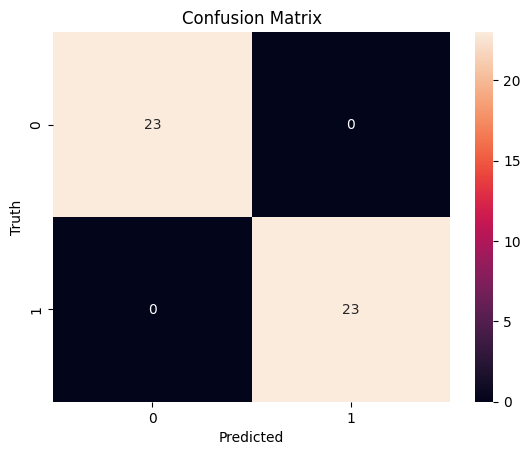

In [ ]:
preds = trainer.predict(tokenized_test)

# Assuming you're working with a problem where softmax output is used,
# You need to extract the actual predictions
predictions = np.argmax(preds.predictions, axis=1)

# Now, `predictions` contains the predicted labels for each input in `tokenized_test`

# Ground Truth labels for your test set
GT = df_test['label'].tolist()

# Classification Report
print(classification_report(GT, predictions))

# Computing the Confusion Matrix
cm = confusion_matrix(GT, predictions)

# Plotting the Confusion Matrix using Seaborn's heatmap
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Confusion Matrix")
plt.show()